### 【[K線捕手](https://www.facebook.com/kevinyang20180801)盤前快訊】櫃買短多，加權盤整  
加權指數昨天開低走低，終場小跌85點，成交量縮至2794億，收在16634的位置，壓力區多次無法攻克，顯見近3周以來，重複提到的16650，短線上是有效的壓力區。  
留意未來日KD是否死亡交叉，屆時就可以宣告震盪和反彈結束，會再出現新一波回測整理。中期趨勢依照扣抵計算，季線有20個交易日會持續下彎，而月線在過5天反而有機會上揚，持續維持盤整格局。  
昨天也提到要將重點放在櫃買指數，櫃買指數相對穩定，維持平盤之上，少部分次族群中小型股有表現，不過投資人不要過度樂觀，畢竟還是定調為短多，未來進入213-218的位置就是壓力區。  
之後還是有很高的機率再回測中長期頸線，積極的投資人可以少量資金搶短，但保守的投資人可以繼續追蹤即可，不用急著進場，可以靜待中期趨勢明朗。  
昨天8月31日，正式收月KD，不過國際股市除陸港股櫃買指數已經死亡交叉之外，大部分KD值只是剛好點到，或是仍維持鈍化區，還不能完全確認死亡交叉，所以8月勉強算是有守住，不過這個指標是動態的，風險尚未解除，所以9月持續追蹤。  
最後，有同學問到，先前規劃的樂觀(紅色)跟悲觀(藍色)的頭部頸線，現在究竟應該看哪一條？當然藍色會比較標準一點，但其實兩者相去不遠，解讀上也差不多，都是做頭後的整理，所以兩條皆可。 (出處：K線捕手楊忠憲粉絲團)  
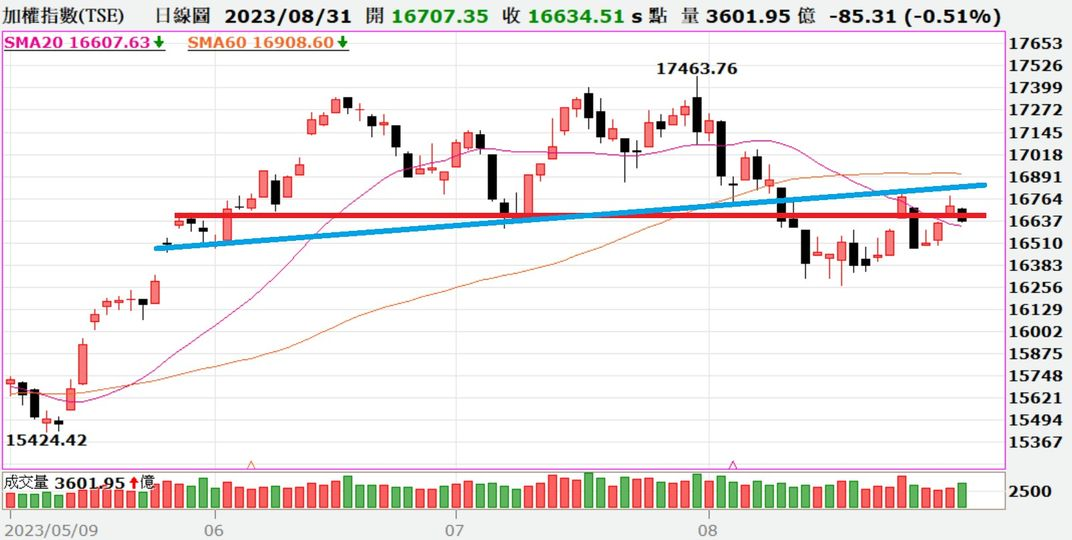

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import mplfinance as mpf
import numpy as np

In [2]:
##### 使用2023年5月9日到今天收盤(2023年9月1日)的日K線資料繪製 #####

# 載入從「好神通PLUS」輸出的Excel檔
df = pd.read_excel('./data/SINO_TSE_230901.xlsx')

# 保存K棒的基本資訊(開、高、低、收、量)
df_k_line = df.drop(columns=['SMA5','SMA10','SMA20','SMA60','SMA120','SMA240','MA5','MA10', 'DIF12-26','MACD9','OSC','K(9,3)','D(9,3)'])

# 保存價的均線
df_sma = df.drop(columns=['開盤價','最高價','最低價','收盤價','成交量','MA5','MA10', 'DIF12-26','MACD9','OSC','K(9,3)','D(9,3)']) 

# 將K棒的Columns的名稱由中文改為英文
df_k_line = df_k_line.rename(columns={'時間':'Date','開盤價':'Open','最高價':'High','最低價':'Low','收盤價':'Close','成交量':'Volume'})

# 將價的均線的Columns的名稱由中文改為英文
df_sma = df_sma.rename(columns={'時間':'Date'})

# 將K棒的Date設為Index
df_k_line.set_index(df_k_line['Date'],inplace=True)
df_k_line = df_k_line.drop(columns=['Date'])

# 將價的均線的Date設為Index
df_sma.set_index(df_sma['Date'],inplace=True)
df_sma = df_sma.drop(columns=['Date'])

In [3]:
def date_to_index(df_in,date_in) :
    number_array = df_in.index == date_in
    idx = 0
    for number_index in number_array :
        if number_index == True :
            break
        idx = idx + 1
    return idx

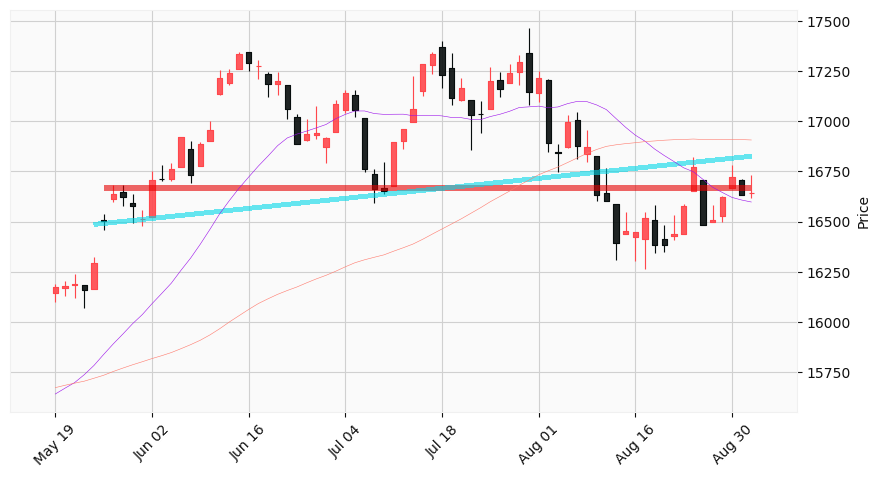

In [4]:
# 設定頸線(紅)
neckline_red_price = df_k_line.loc['2023-07-10']['Open']
neckline_red_start_date = '2023-05-26'
neckline_red_end_date = '2023-09-01'

# 設定頸線(藍)
neckline_blue_x_date = ['2023-06-01','2023-07-10']
neckline_blue_x = [date_to_index(df_k_line,neckline_blue_x_date[0]),date_to_index(df_k_line,neckline_blue_x_date[1])]
neckline_blue_y = [df_k_line.loc[neckline_blue_x_date[0]]['Open'],df_k_line.loc[neckline_blue_x_date[1]]['Low']]
slope,intercept = np.polyfit(neckline_blue_x,neckline_blue_y,1)
neckline_blue_start_date = '2023-05-25'
neckline_blue_start_price = slope * date_to_index(df_k_line,neckline_blue_start_date) + intercept
neckline_blue_end_date = '2023-09-01'
neckline_blue_end_price = slope * date_to_index(df_k_line,neckline_blue_end_date) + intercept

# 設定K線格式
mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)

# 設定頸線
seq_of_seq_of_points=[
    [(neckline_red_start_date,neckline_red_price),(neckline_red_end_date,neckline_red_price)],
    [(neckline_blue_start_date,neckline_blue_start_price),(neckline_blue_end_date,neckline_blue_end_price)]
                     ]

# 設定均線
added_plots={
    "SMA20": mpf.make_addplot(df_sma['SMA20'],width=0.4,color='xkcd:violet'),
    "SMA60": mpf.make_addplot(df_sma['SMA60'],width=0.4,color='xkcd:salmon')
            }


# 繪製K線圖
kwargs = dict(type='candle', style=s, figratio=(19,10), addplot=list(added_plots.values()), alines=dict(alines=seq_of_seq_of_points, linewidths=(3.0,2.8), colors=('xkcd:red','xkcd:aqua blue'), alpha=0.6))
mpf.plot(df_k_line,**kwargs)

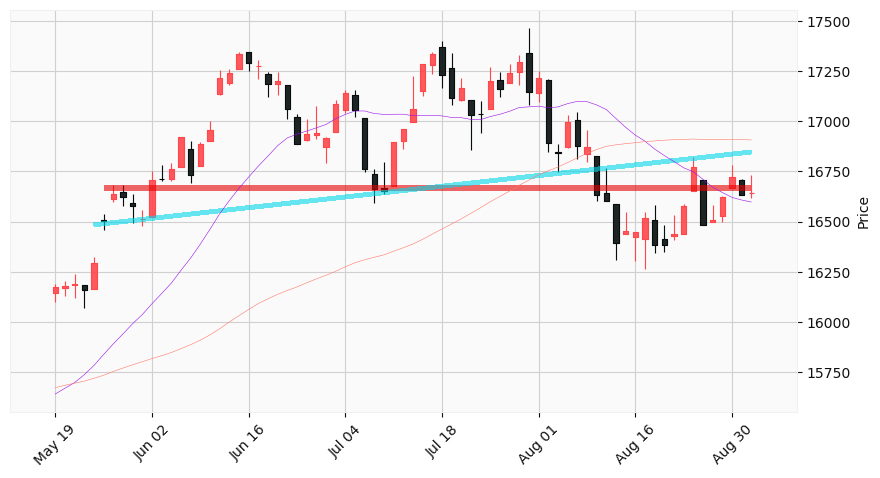

In [5]:
# 設定頸線(藍)
neckline_blue_x_date = ['2023-06-01','2023-08-11']
neckline_blue_x = [date_to_index(df_k_line,neckline_blue_x_date[0]),date_to_index(df_k_line,neckline_blue_x_date[1])]
neckline_blue_y = [df_k_line.loc[neckline_blue_x_date[0]]['Open'],df_k_line.loc[neckline_blue_x_date[1]]['High']]
slope,intercept = np.polyfit(neckline_blue_x,neckline_blue_y,1)
neckline_blue_start_date = '2023-05-25'
neckline_blue_start_price = slope * date_to_index(df_k_line,neckline_blue_start_date) + intercept
neckline_blue_end_date = '2023-09-01'
neckline_blue_end_price = slope * date_to_index(df_k_line,neckline_blue_end_date) + intercept

# 設定K線格式
mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)

# 設定頸線
seq_of_seq_of_points=[
    [(neckline_red_start_date,neckline_red_price),(neckline_red_end_date,neckline_red_price)],
    [(neckline_blue_start_date,neckline_blue_start_price),(neckline_blue_end_date,neckline_blue_end_price)]
                     ]

# 設定均線
added_plots={
    "SMA20": mpf.make_addplot(df_sma['SMA20'],width=0.4,color='xkcd:violet'),
    "SMA60": mpf.make_addplot(df_sma['SMA60'],width=0.4,color='xkcd:salmon')
            }


# 繪製K線圖
kwargs = dict(type='candle', style=s, figratio=(19,10), addplot=list(added_plots.values()), alines=dict(alines=seq_of_seq_of_points, linewidths=(3.0,2.8), colors=('xkcd:red','xkcd:aqua blue'), alpha=0.6))
mpf.plot(df_k_line,**kwargs)

                Date     Price Type
DateIndex                          
9         2023-06-01  16511.00   LO
20        2023-06-16  17342.86   HI
28        2023-06-30  16870.27   LO
30        2023-07-04  17140.77   HI
34        2023-07-10  16652.80   LO
40        2023-07-18  17368.36   HI
43        2023-07-21  17030.70   LO
49        2023-07-31  17341.04   HI
62        2023-08-18  16381.31   LO
66        2023-08-24  16770.87   HI


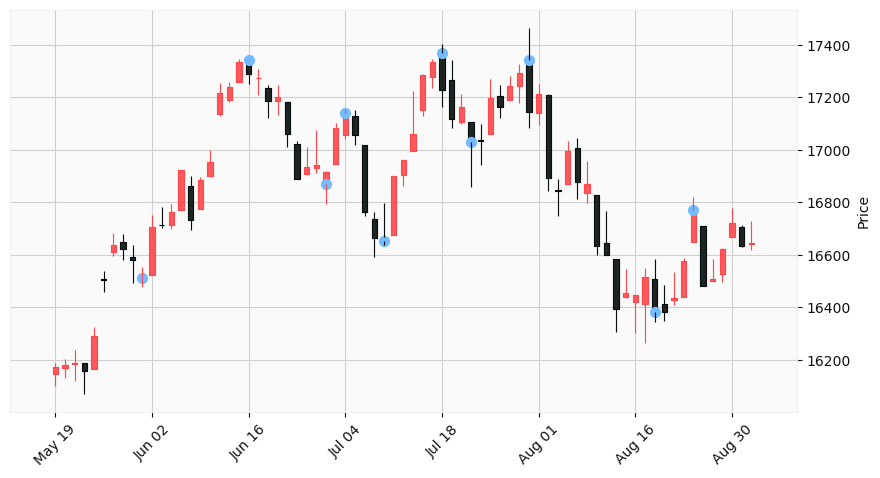

In [6]:
import myutils

# 尋找轉折點
_,_,max_min = myutils.FindingTurningPoints(df_k_line,'open_close',order=3)
print(max_min)

# 設定K線格式
mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)

# 設定均線與轉折點    
turning_points_len = len(np.array(df_k_line['Close']))
turning_points = np.array([np.nan]*turning_points_len)
for point in max_min.iterrows() :
    turning_points[point[0]] = point[1]['Price']    
apds = [
    mpf.make_addplot(turning_points,type='scatter',marker='o',markersize=50,color='xkcd:sky blue')
]

# 繪製K線圖
kwargs = dict(type='candle', style=s, figratio=(19,10), addplot=apds)
mpf.plot(df_k_line,**kwargs)

[美祭新管制緯穎AI大單恐受阻](https://readers.ctee.com.tw/cm/20230901/a01aa1/1256457/share)  
  
[高息ETF金管會嚴打兩亂象](https://readers.ctee.com.tw/cm/20230901/a02aa2/1256462/share)  
  
[藍燈退散 製造業景氣露曙光](https://readers.ctee.com.tw/cm/20230901/a04aa4/1256473/share)  
  
[大陸8月 製造業PMI 優預期](https://readers.ctee.com.tw/cm/20230901/a04aa4/1256474/share)  
  
[9月1日 五件財經大事搶先看](https://money.udn.com/money/story/5607/7408834?from=edn_newestlist_cate_side)  

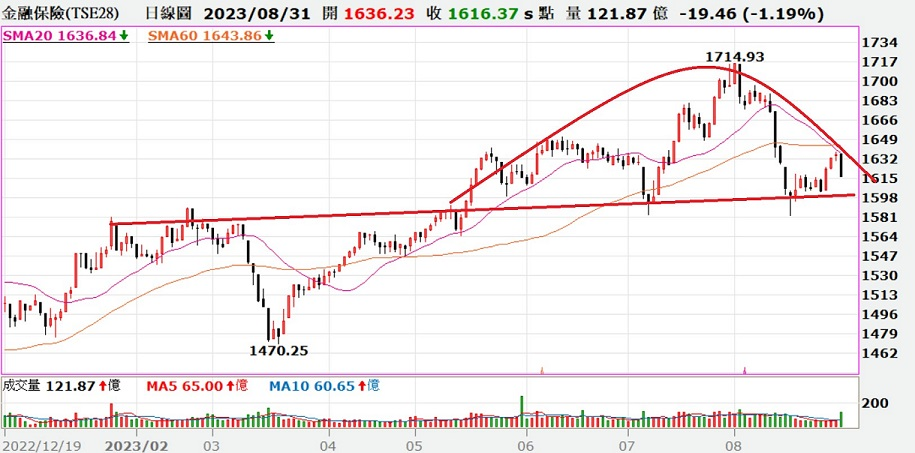  
  
日本開低但回到平盤附近，中期持續高檔箱型整理：  
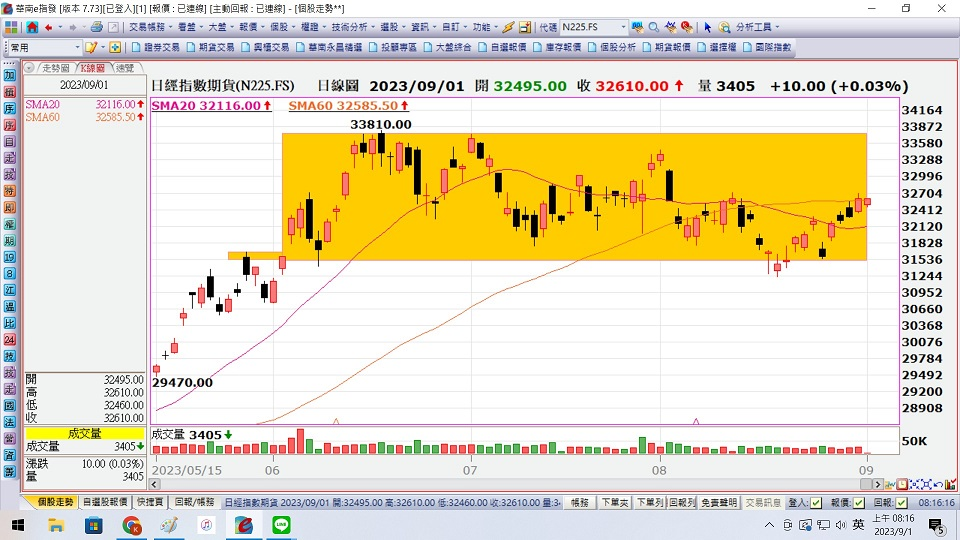  
  
期貨開在平盤附近：  
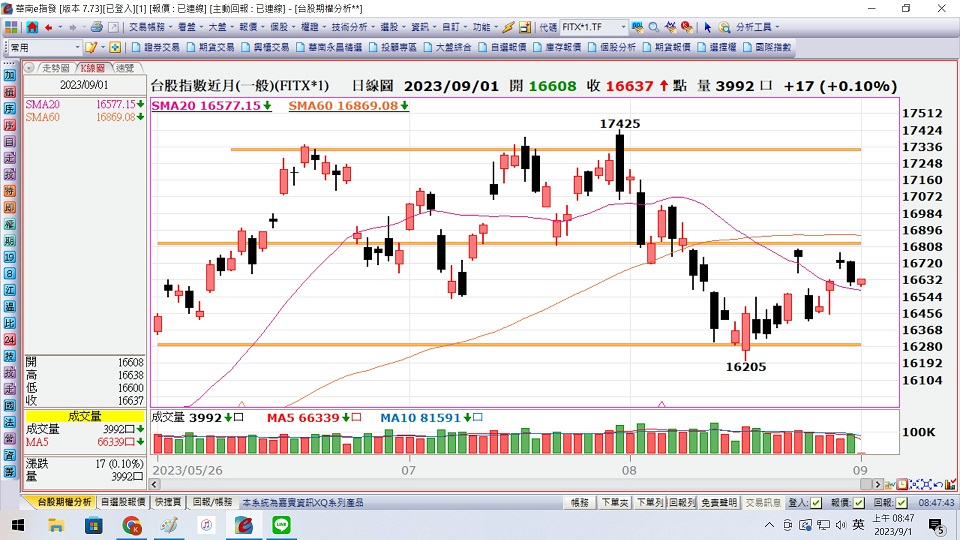    
  
加權平盤，櫃買持續短多，但已經要進入壓力區：  
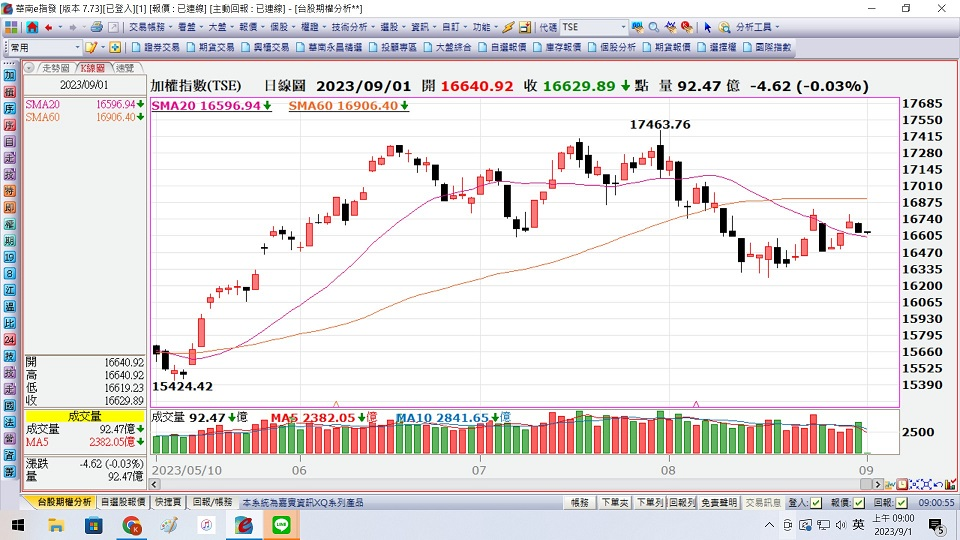  
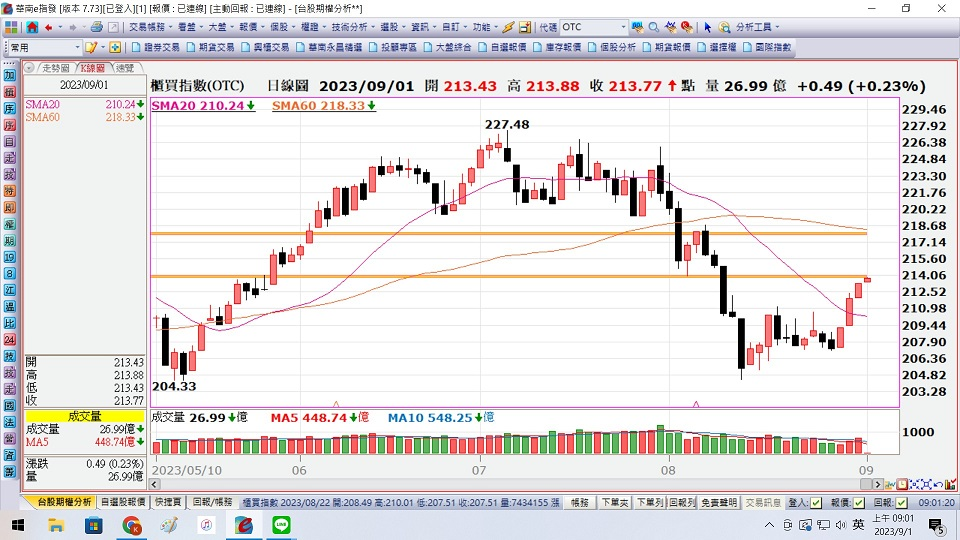  

信昌電(6173)：  
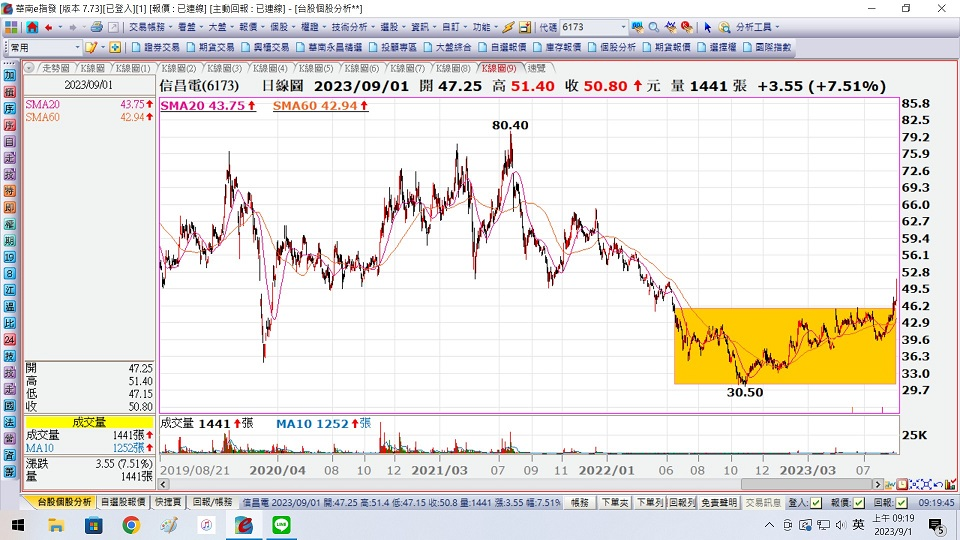

櫃買指數開高走高：  
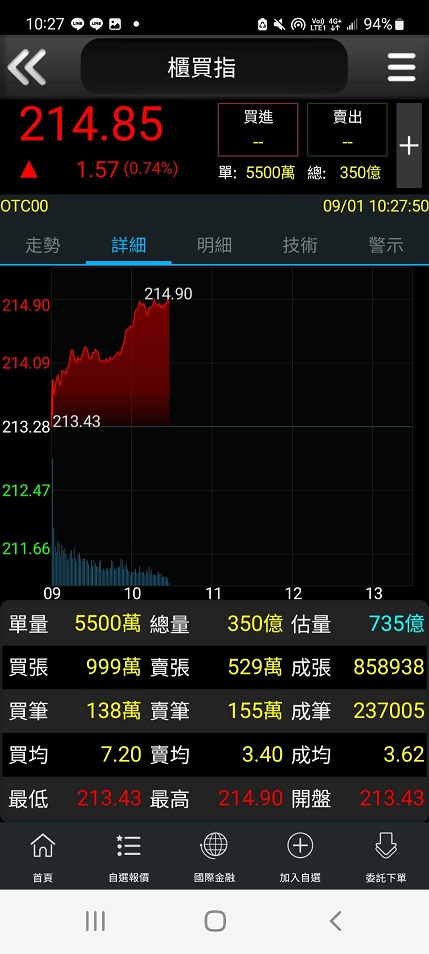  
  
加權指數持續盤整：  
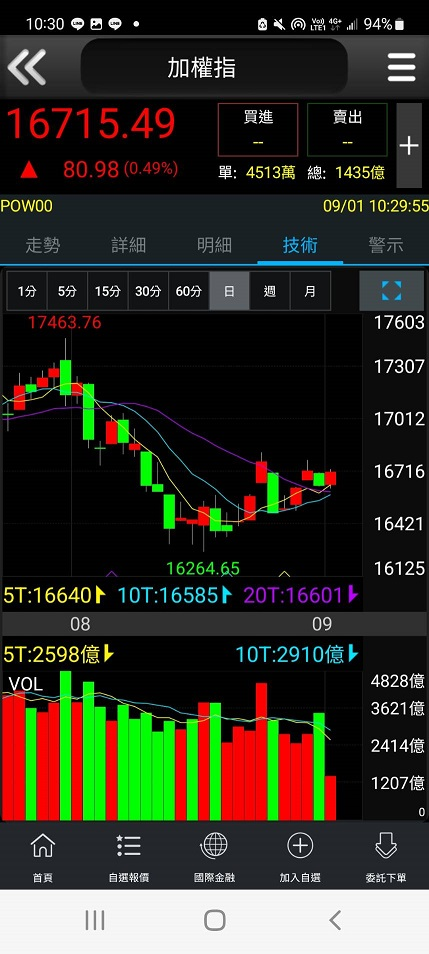  
  
進入早上說壓力區，開始出現賣壓。  
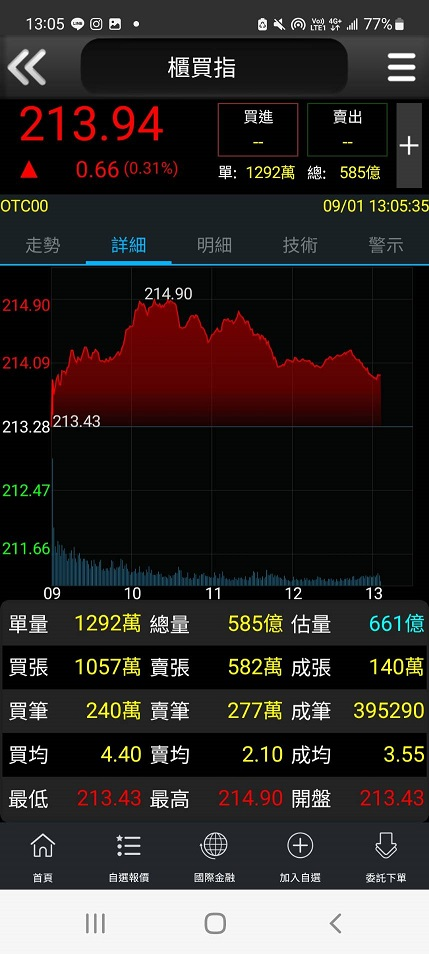

其實這星期外資期現貨，都是忽多忽空的，也符合指數的走勢，維持區間盤整。收在16644，差16點就16650。  
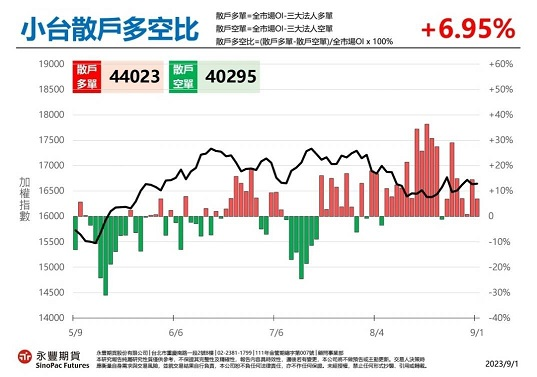  
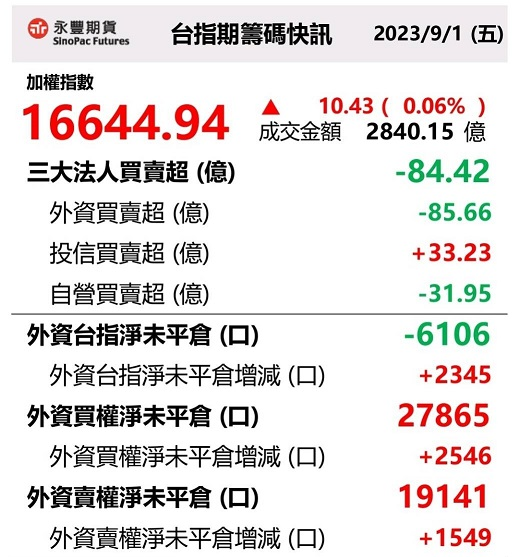  

### 史塔克財金工作室  

【技術分析報到流程】  
步驟一：先確認要繳交的費用(參考附圖)。  
步驟二：請將費用匯至華南銀行水湳分行(參考附圖)。  
步驟三：臨櫃匯款請註記匯款人，如ATM匯款，請提供帳號末五碼。  
步驟四：匯款完成後請私訊忠憲老師並提供  
  
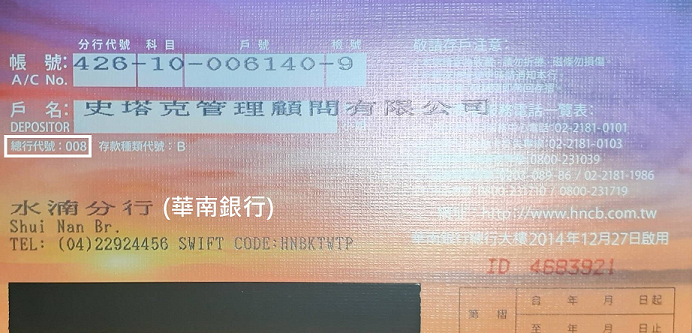  
    
【回傳訊息】  
1.姓名(有發票需要本名，不然如果中獎不能領獎)  
2.發票地址  
3.匯款金額  
4.帳號末五碼  
5.翻拍匯款資料或存根圖檔  
  
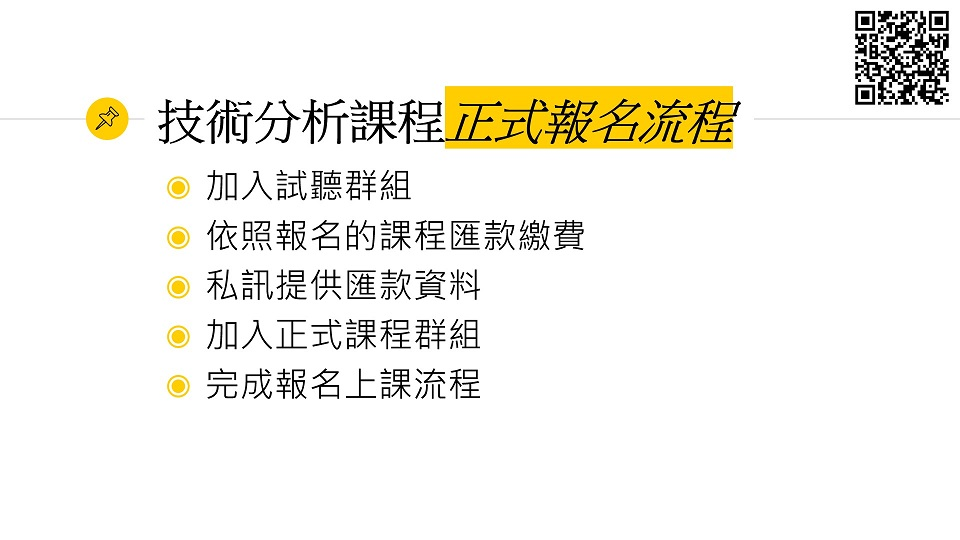  
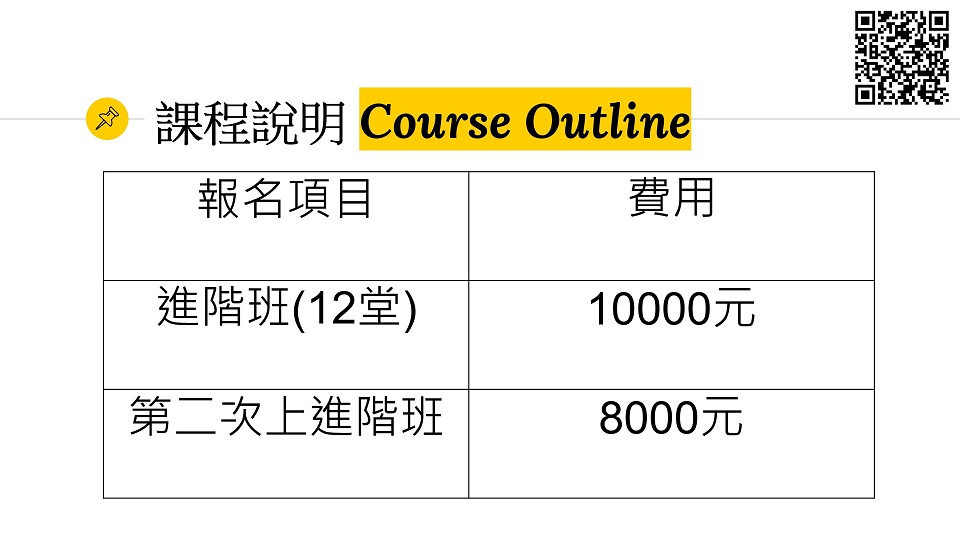
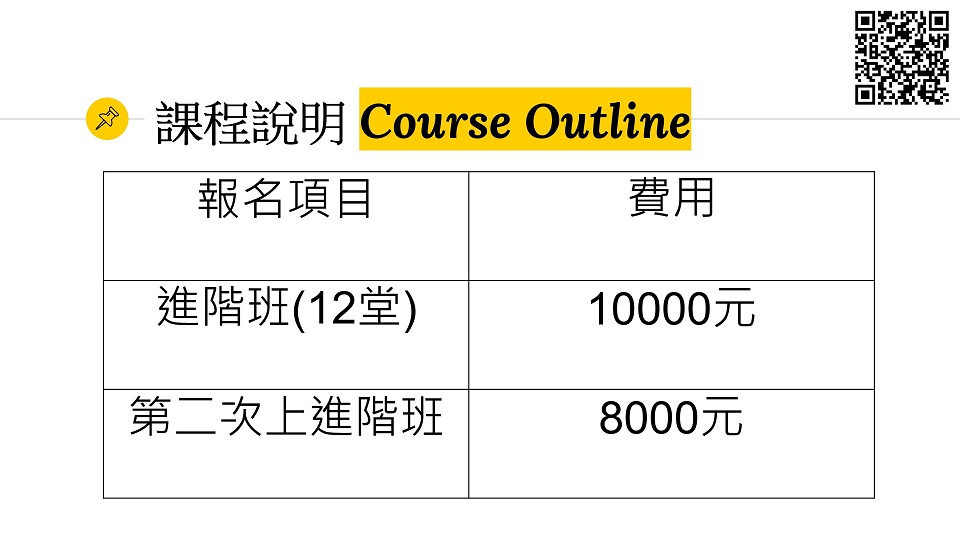

### 本日進度  
* **暫時空手**，觀察後續盤勢發展。  
* [2023 iThome 鐵人賽](https://ithelp.ithome.com.tw/2023ironman/event) – 用Python程式進行股票技術分析：[Day1 將股票技術分析程式化](https://ithelp.ithome.com.tw/articles/10314112) 